In [7]:
#importing libraries
import pandas as pd 
import ast
import matplotlib.pyplot as plt 
from datasets import load_dataset 
from adjustText import adjust_text
import seaborn as sns
import matplotlib.ticker as mticker

# load data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

# filter for data anallyst data
df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

# Customizing our chart from 12_Excercise_Trending_Skills.ipynb

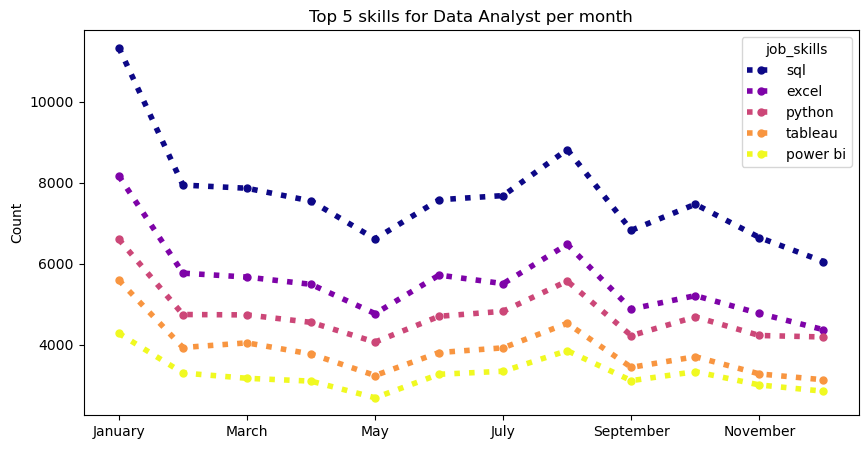

In [8]:
df_da['job_posted_month_no'] = df_da['job_posted_date'].dt.month

# explode the job_skills column and pivot
df_da_explode = df_da.explode('job_skills')
df_da_pivot = df_da_explode.pivot_table(index = 'job_posted_month_no', columns = 'job_skills', aggfunc = 'size', fill_value = 0)

#sort the skills by count
df_da_pivot.loc['Total'] = df_da_pivot.sum()
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending = False).index]
df_da_pivot = df_da_pivot.drop('Total')

# Use month names for plotting
df_da_pivot = df_da_pivot.reset_index()
df_da_pivot['job_posted_month'] = df_da_pivot['job_posted_month_no'].apply(lambda x:pd.to_datetime(x, format= '%m').strftime('%B'))
df_da_pivot = df_da_pivot.set_index('job_posted_month')
df_da_pivot = df_da_pivot.drop(columns='job_posted_month_no')

# get the top 5 skills
df_da_pivot.iloc[:,:5].plot(
    kind = 'line',
    linewidth = 4,
    linestyle = ':', # options: '-', '--', '-.', ':'
    colormap = 'plasma', # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis'  
    marker = 'o', # options: 'o', 'x', '+', '*', 's', ',', '1', '2', '3', '4',...  
    markersize = 5,
    figsize=(10,5)
)

plt.title('Top 5 skills for Data Analyst per month')
plt.xlabel('')
plt.ylabel('Count')
plt.show()                                                                           

In [3]:
df_da_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month,,,,,,,,,,,,,,,,,,,,,
January,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
February,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
March,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
April,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
May,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
June,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
July,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
August,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
September,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


In [4]:
# explode the 'job_skills' into individual rows
df_exploded = df_da.explode('job_skills')

#calculate the average salary and count of job postings per skill
skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary = ('salary_year_avg','median'),
    skill_count = ('job_skills', 'count')
    
)

# limit to top skills
skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending = False).head(skill_count)

skill_stats

,median_salary,skill_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


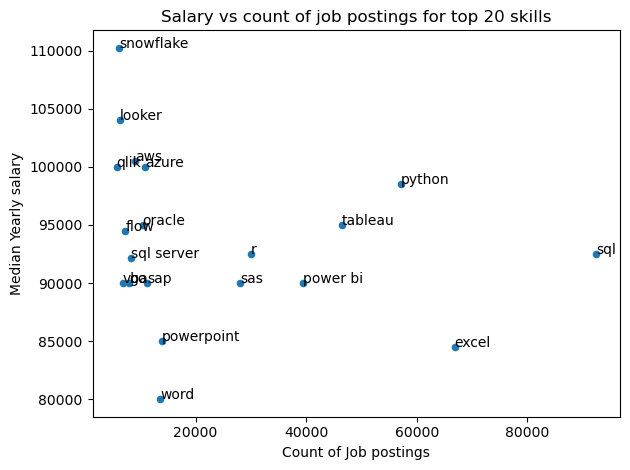

In [5]:
skill_stats.plot(kind='scatter', x = 'skill_count', y = 'median_salary')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i],txt)
    
plt.xlabel('Count of Job postings')
plt.ylabel('Median Yearly salary')
plt.title(f'Salary vs count of job postings for top {skill_count} skills')
plt.tight_layout()
plt.show()

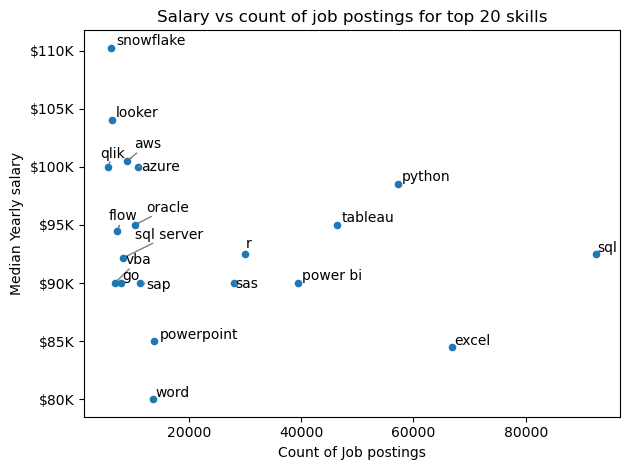

In [6]:
# fig, ax = plt.subplots()
skill_stats.plot(kind='scatter', x = 'skill_count', y = 'median_salary')

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i],txt))

adjust_text(texts, arrowprops= dict(arrowstyle="->", color='gray',lw=1))  
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.xlabel('Count of Job postings')
plt.ylabel('Median Yearly salary')
plt.title(f'Salary vs count of job postings for top {skill_count} skills')
plt.tight_layout()
plt.show()